# Levine et al. (2015) -- Mass Cytometry of Human Bone Marrow (32-dim)

**Source:** Levine et al., "Data-Driven Phenotypic Dissection of AML Reveals Progenitor-like Cells that Correlate with Prognosis." *Cell* 162.1 (2015): 184--197.

265,627 human bone marrow cells profiled by mass cytometry (CyTOF) across 32 protein markers, with 14 manually gated cell populations (39% of cells labeled = 104,184 cells). CyTOF data features heavy-tailed protein expression distributions and overlapping cell populations with varying densities -- properties known to challenge classical distance-based validation indices (Silhouette, Davies--Bouldin, Calinski--Harabasz).

Available via the HDCytoData Bioconductor package (Weber & Robinson, 2016).

---

## 0. Imports & Configuration

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "notebooks" / "benchmarking_code"))

In [2]:
import multiprocessing
import os, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import RobustScaler

from carve import CARVE
from carve.cluster import SpectralClusteringCARVE

from case_study_plotting import (
    plot_dim_red,
    plot_cluster_scatter,
    plot_carve_best_lines,
    plot_baseline_best_lines,
    baseline_metrics_over_k,
    build_baseline_best_labels,
    prepare_composite_data,
    extract_ari_comparison,
    plot_ari_comparison_bar,
)

In [3]:
# --- Configuration ---
import case_study_plotting as csp

# "tab20", "tab20b", "tab20c", "Set3", "Paired", "Dark2"
PALETTE_NAME = "tab20"
csp.CLUSTER_PALETTE_NAME = PALETTE_NAME

SUBSAMPLE = True
subsample_size = 5000
RANDOM_SEED = 42
K = 17

# CARVE selection criteria
MEASURE = "s"  # stability
RULE = "1se"
NOT_TWO = True

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)


def get_n_jobs():
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4
    return max(1, n_cores - 1)


N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


---

## 1. Load & Preprocess Data

Load from the HDCytoData R package via rpy2. Filter to labeled cells and type markers, apply arcsinh transform (CyTOF standard, cofactor=5) and robust scaling.

In [5]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

ro.r(r"""
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
if (!requireNamespace("HDCytoData", quietly=TRUE)) BiocManager::install("HDCytoData")
library(HDCytoData)
library(SummarizedExperiment)
""")

ro.r("sce <- Levine_32dim_SE()")

X_all = np.array(ro.r("assay(sce)"), dtype=float)
row_df = pandas2ri.rpy2py(ro.r("as.data.frame(rowData(sce))"))
col_df = pandas2ri.rpy2py(ro.r("as.data.frame(colData(sce))"))

print(f"Full dataset: {X_all.shape[0]:,} cells x {X_all.shape[1]} markers")
print(f"Populations: {row_df['population_id'].nunique()} unique")
print(
    f"Labeled cells: {(row_df['population_id'] != 'unassigned').sum():,} / {X_all.shape[0]:,}"
)

R callback write-console: Loading required package: ExperimentHub
  
R callback write-console: Loading required package: BiocGenerics
  
R callback write-console: Loading required package: generics
  
R callback write-console: 
Attaching package: ‘generics’

  
R callback write-console: The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union

  
R callback write-console: 
Attaching package: ‘BiocGenerics’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

  
R callback write-console: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames,

Full dataset: 265,627 cells x 39 markers
Populations: 15 unique
Labeled cells: 265,627 / 265,627


In [6]:
# Filter to labeled cells only
labeled_mask = (row_df["population_id"] != "unassigned").to_numpy()
X_labeled = X_all[labeled_mask]
y_labeled = row_df["population_id"].to_numpy()[labeled_mask]

# Filter to type markers (marker_class == 2)
keep_markers = (col_df["marker_class"].astype(int) == 2).to_numpy()
X_labeled = X_labeled[:, keep_markers]
marker_names = col_df.index[keep_markers].tolist()

print(f"Labeled cells: {X_labeled.shape[0]:,} x {X_labeled.shape[1]} markers")
print(f"Populations: {len(np.unique(y_labeled))}")
print()
print("Population distribution:")
print(pd.Series(y_labeled).value_counts().to_string())

Labeled cells: 265,627 x 32 markers
Populations: 15

Population distribution:
15    161443
7      26366
10     21099
8      20108
9      16520
13      6135
2       3905
4       3295
3       2248
11      1238
1       1207
6        916
14       513
12       330
5        304


In [7]:
# Arcsinh transform (CyTOF standard) + robust scaling
cofactor = 5.0
X_transformed = np.arcsinh(X_labeled.astype(np.float64) / cofactor)
X_scaled = RobustScaler(quantile_range=(10, 90)).fit_transform(X_transformed)

In [8]:
# Remove population 15 from the labeled dataset
keep_mask = y_labeled != 15

y_labeled = y_labeled[keep_mask]
X_labeled = X_labeled[keep_mask]
X_transformed = X_transformed[keep_mask]
X_scaled = X_scaled[keep_mask]

print(
    f"After removing population 15: {X_scaled.shape[0]:,} cells x {X_scaled.shape[1]} markers"
)
print("Remaining populations:", np.unique(y_labeled))

After removing population 15: 104,184 cells x 32 markers
Remaining populations: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]


---

## 2. Subsampling & Visualization

In [9]:
X = X_scaled
y = pd.Series(y_labeled, name="population_id")

if SUBSAMPLE:
    if isinstance(subsample_size, float):
        subsample_size = int(subsample_size * X.shape[0])
    frac = subsample_size / X.shape[0]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=frac, random_state=RANDOM_SEED)
    _, idx = next(sss.split(X, y))
    selected_idx = y.index[idx]
    X = X[idx]
    y = y.loc[selected_idx]
    print(f"Subsampled to {X.shape[0]:,} cells ({frac:.0%})")

print(f"Final: {X.shape[0]:,} cells x {X.shape[1]} markers, {y.nunique()} populations")

Subsampled to 5,000 cells (5%)
Final: 5,000 cells x 32 markers, 14 populations


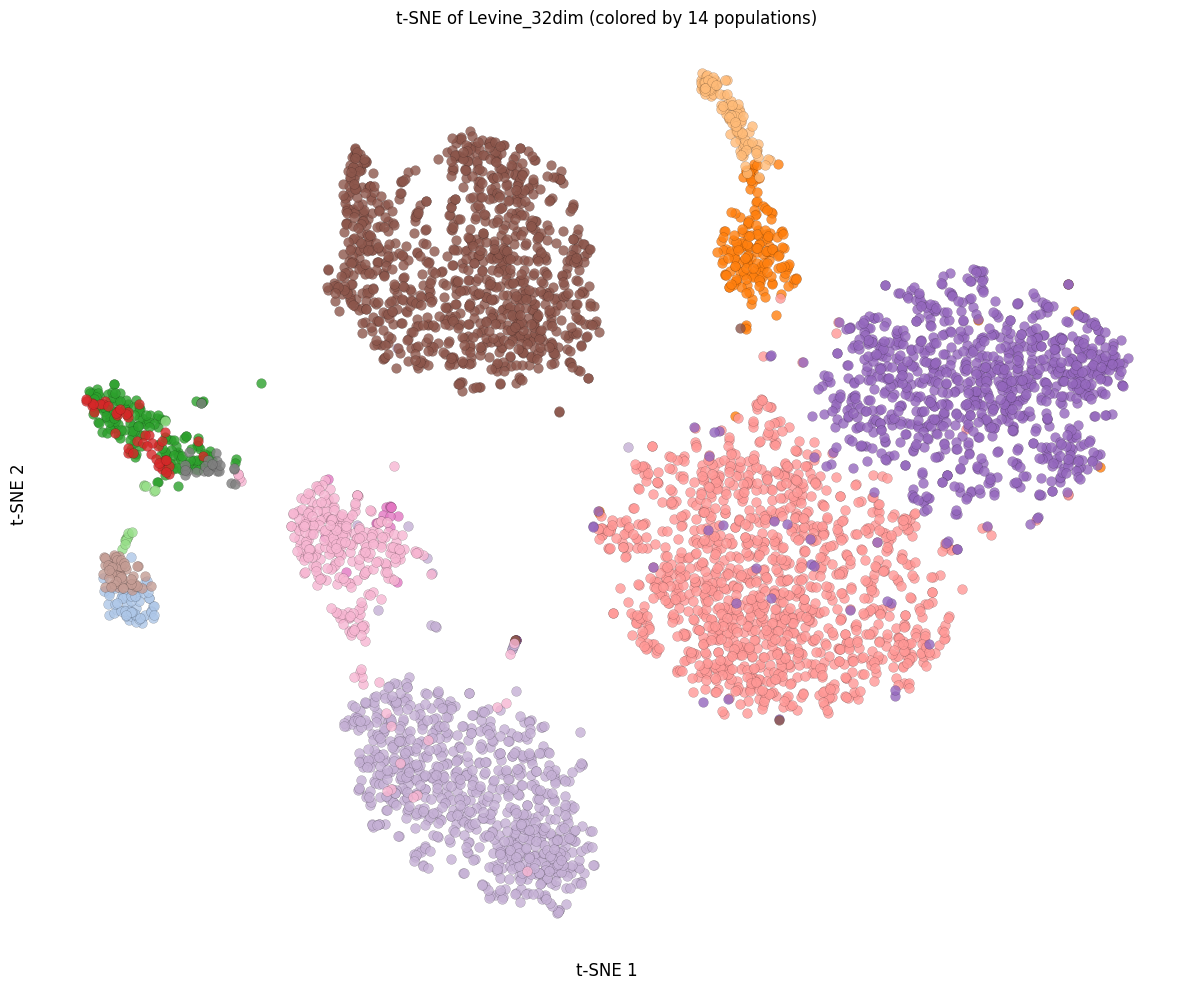

In [10]:
plot_dim_red(
    X=X,
    y=y,
    method="tsne",
    show_legend=False,
    title="t-SNE of Levine_32dim (colored by 14 populations)",
)

---

## 3. Baseline Metrics

We evaluate Silhouette, Gap statistic, Davies-Bouldin, and Calinski-Harabasz across k = 7, ..., 17 for KMeans and spectral clustering (with self-tuning affinity):

In [11]:
ks = list(range(7, K + 1))

model_grids = [
    (KMeans, {"n_clusters": ks}),
    (SpectralClusteringCARVE, {"n_clusters": ks, "affinity": ["self_tuning"]}),
]


baseline selections (max metric):
  - Silhouette: k=7, score=0.2410, ari=0.6232   [KMeans]
  - Gap Statistic: k=15, score=2.5642, ari=0.4900   [SpectralCARVE (affinity=self_tuning)]
  - DB: k=7, score=0.4323, ari=0.6232   [KMeans]
  - CH: k=7, score=751.0069, ari=0.6232   [KMeans]


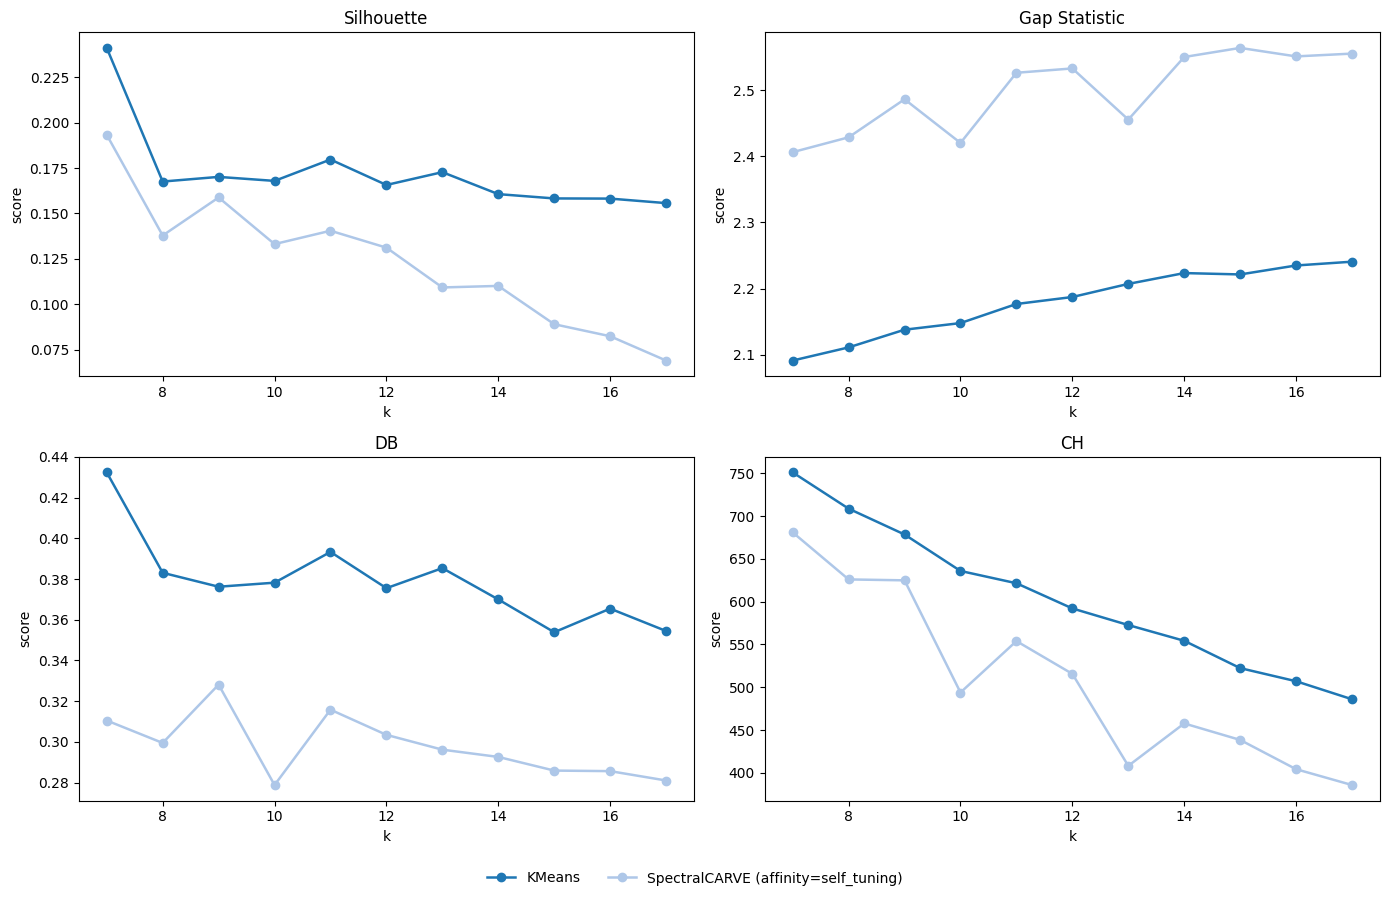

In [12]:
curves_df, best_df = baseline_metrics_over_k(
    X,
    y=y,
    model_grids=model_grids,
    metrics=["silhouette", "gap", "DB", "CH"],
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
    ncols=2,
    figsize=(14, 9),
)

In [13]:
print("Best k selected by each metric:")
print(best_df[["metric", "best_model", "best_k", "best_ari"]].to_string(index=False))

Best k selected by each metric:
    metric                           best_model  best_k  best_ari
silhouette                               KMeans       7  0.623232
       gap SpectralCARVE (affinity=self_tuning)      15  0.490009
        DB                               KMeans       7  0.623232
        CH                               KMeans       7  0.623232


---

## 4. CARVE Analysis

In [14]:
carve_path = Path("./carve_state_saves/carve_levine32.carve")

if not carve_path.is_file():
    carve = CARVE(
        estimator_param_grids=model_grids, n_jobs=N_JOBS, random_state=RANDOM_SEED
    )
    carve.fit(X, reference_labels=y)

    # Save fitted state to avoid re-running
    carve_path.parent.mkdir(parents=True, exist_ok=True)
    carve.save(str(carve_path))
    print(f"Saved CARVE state to {carve_path}")
else:
    print(f"Loading CARVE state from {carve_path}")
    carve = CARVE.load(str(carve_path))
    carve.X_ = X

Loading CARVE state from carve_state_saves/carve_levine32.carve


/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:295: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:295: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:295: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:442: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/kaiwycik/GitHub/ClusteringValidation/code/src/carve/_plotting.py:972: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users

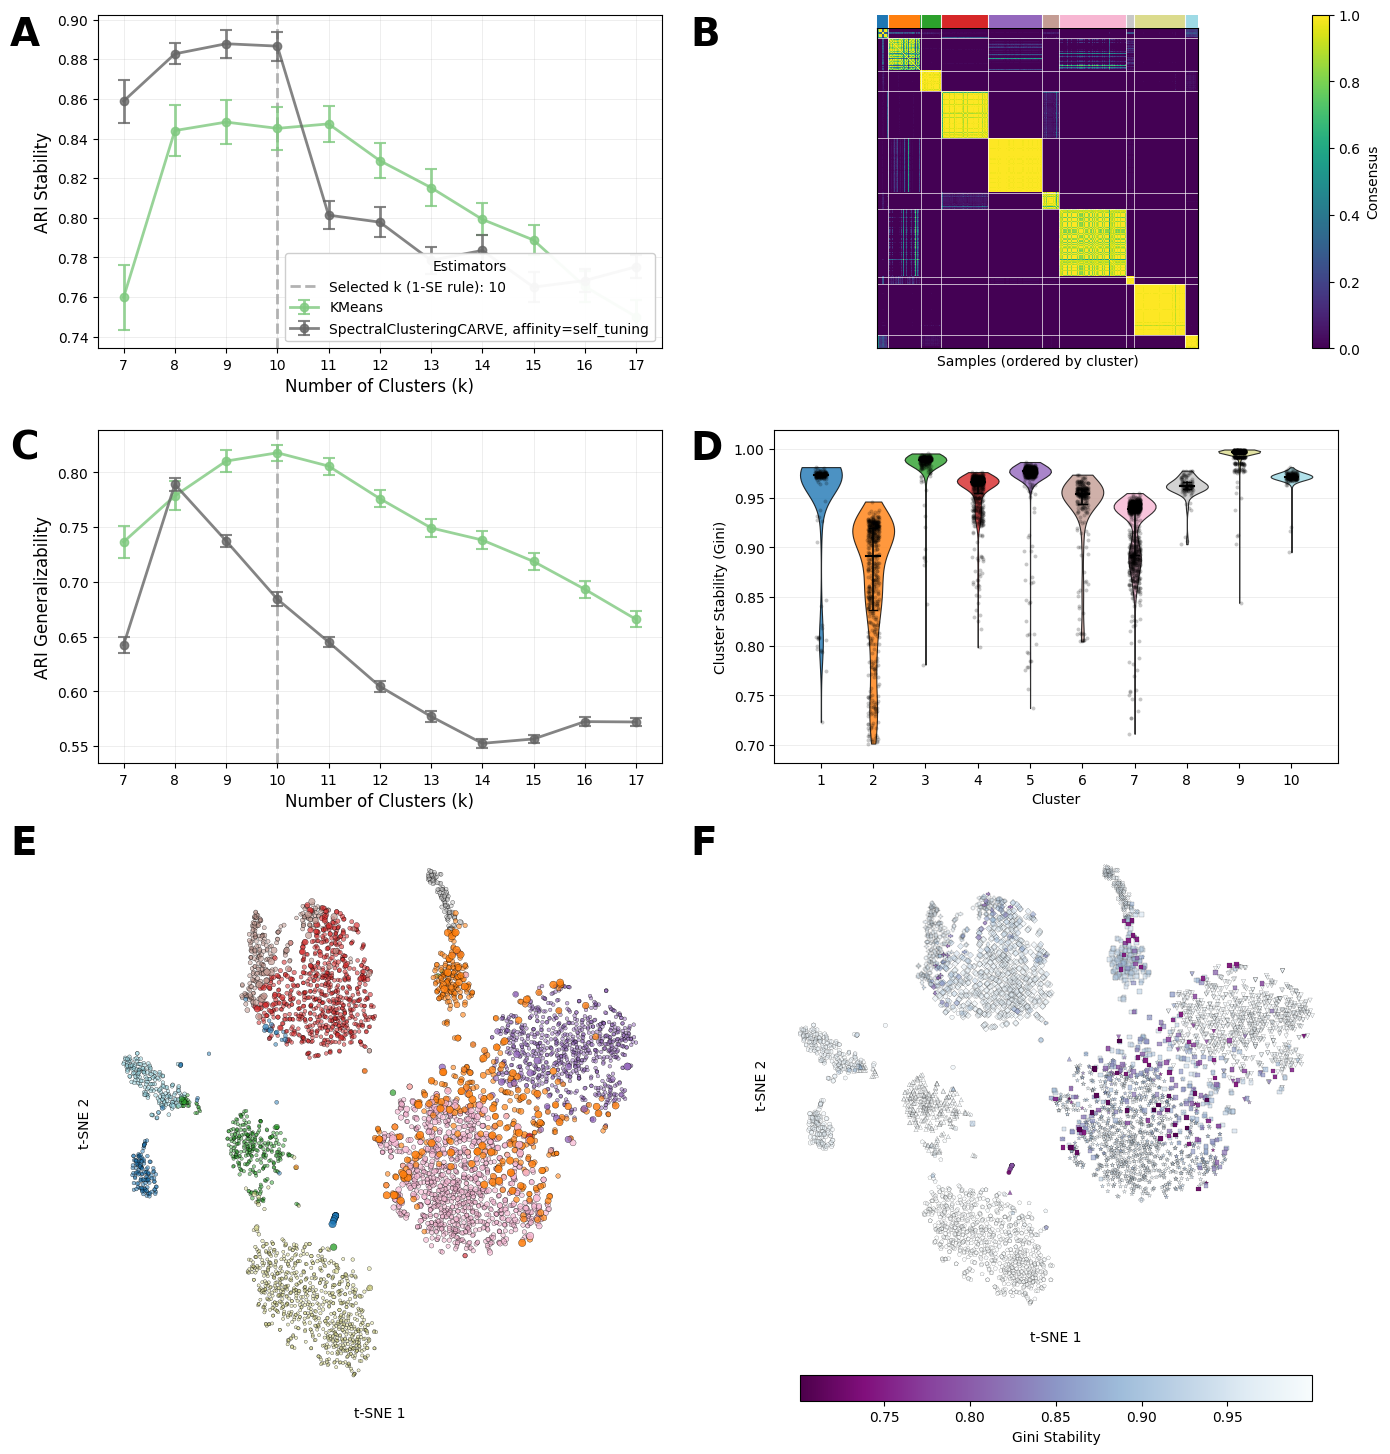

In [15]:
if "tsne_embedding" not in globals():
    tsne_embedding = TSNE(random_state=RANDOM_SEED).fit_transform(X)


fig = plt.figure(figsize=(16, 18), constrained_layout=True)
gs = fig.add_gridspec(
    3, 2, height_ratios=[0.6, 0.6, 1.0], width_ratios=[1.0, 1.0], wspace=0.2
)
ax_l1 = fig.add_subplot(gs[0, 0])
ax_l2 = fig.add_subplot(gs[1, 0])
ax_m1 = fig.add_subplot(gs[0, 1])
ax_m2 = fig.add_subplot(gs[1, 1])
ax_r1 = fig.add_subplot(gs[2, 0])
ax_r2 = fig.add_subplot(gs[2, 1])


carve.plot_metric_over_n_clusters(
    measure="stability", rule=RULE, not_two=NOT_TWO, legend_loc="lower right", ax=ax_l1
)

carve.plot_metric_over_n_clusters(
    measure="generalizability", rule=RULE, not_two=NOT_TWO, ax=ax_l2, legend=False
)

carve.plot_consensus_matrix(
    measure="stability", rule=RULE, not_two=NOT_TWO, ax=ax_m1, palette=PALETTE_NAME
)

carve.plot_cluster_violin(
    measure="stability",
    rule=RULE,
    not_two=NOT_TWO,
    ax=ax_m2,
    annotation=False,
    fit_ylim=True,
    palette=PALETTE_NAME,
)

carve.plot_cluster_scatter(
    measure="stability",
    rule=RULE,
    not_two=NOT_TWO,
    embedding=tsne_embedding,
    ax=ax_r1,
    palette=PALETTE_NAME,
    alpha_range=(0.45, 0.9),
    size_range=(5, 30),
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
    legend=False,
)

carve.plot_diagnostic_scatter(
    measure="stability",
    rule=RULE,
    not_two=NOT_TWO,
    embedding=tsne_embedding,
    alpha_range=(0.3, 1.0),
    marker_size=10,
    marker_linewidth=0.1,
    ax=ax_r2,
    cmap="BuPu_r",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
    legend=False,
)


fig.text(0.07, 0.88, "A", fontsize=28, fontweight="bold", va="top", ha="left")
fig.text(0.495, 0.88, "B", fontsize=28, fontweight="bold", va="top", ha="left")
fig.text(0.07, 0.65, "C", fontsize=28, fontweight="bold", va="top", ha="left")
fig.text(0.495, 0.65, "D", fontsize=28, fontweight="bold", va="top", ha="left")
fig.text(0.07, 0.43, "E", fontsize=28, fontweight="bold", va="top", ha="left")
fig.text(0.495, 0.43, "F", fontsize=28, fontweight="bold", va="top", ha="left")

plt.tight_layout()
plt.show()

In [16]:
print(
    f"CARVE selects k={carve.get_k(measure=MEASURE, rule=RULE, not_two=NOT_TWO)} "
    f"(measure={MEASURE}, rule={RULE}, not_two={NOT_TWO})"
)

CARVE selects k=10 (measure=s, rule=1se, not_two=True)


---

## 5. Quantitative Comparison

### 5.1 Composite Paper Figure (with ARI Comparison)

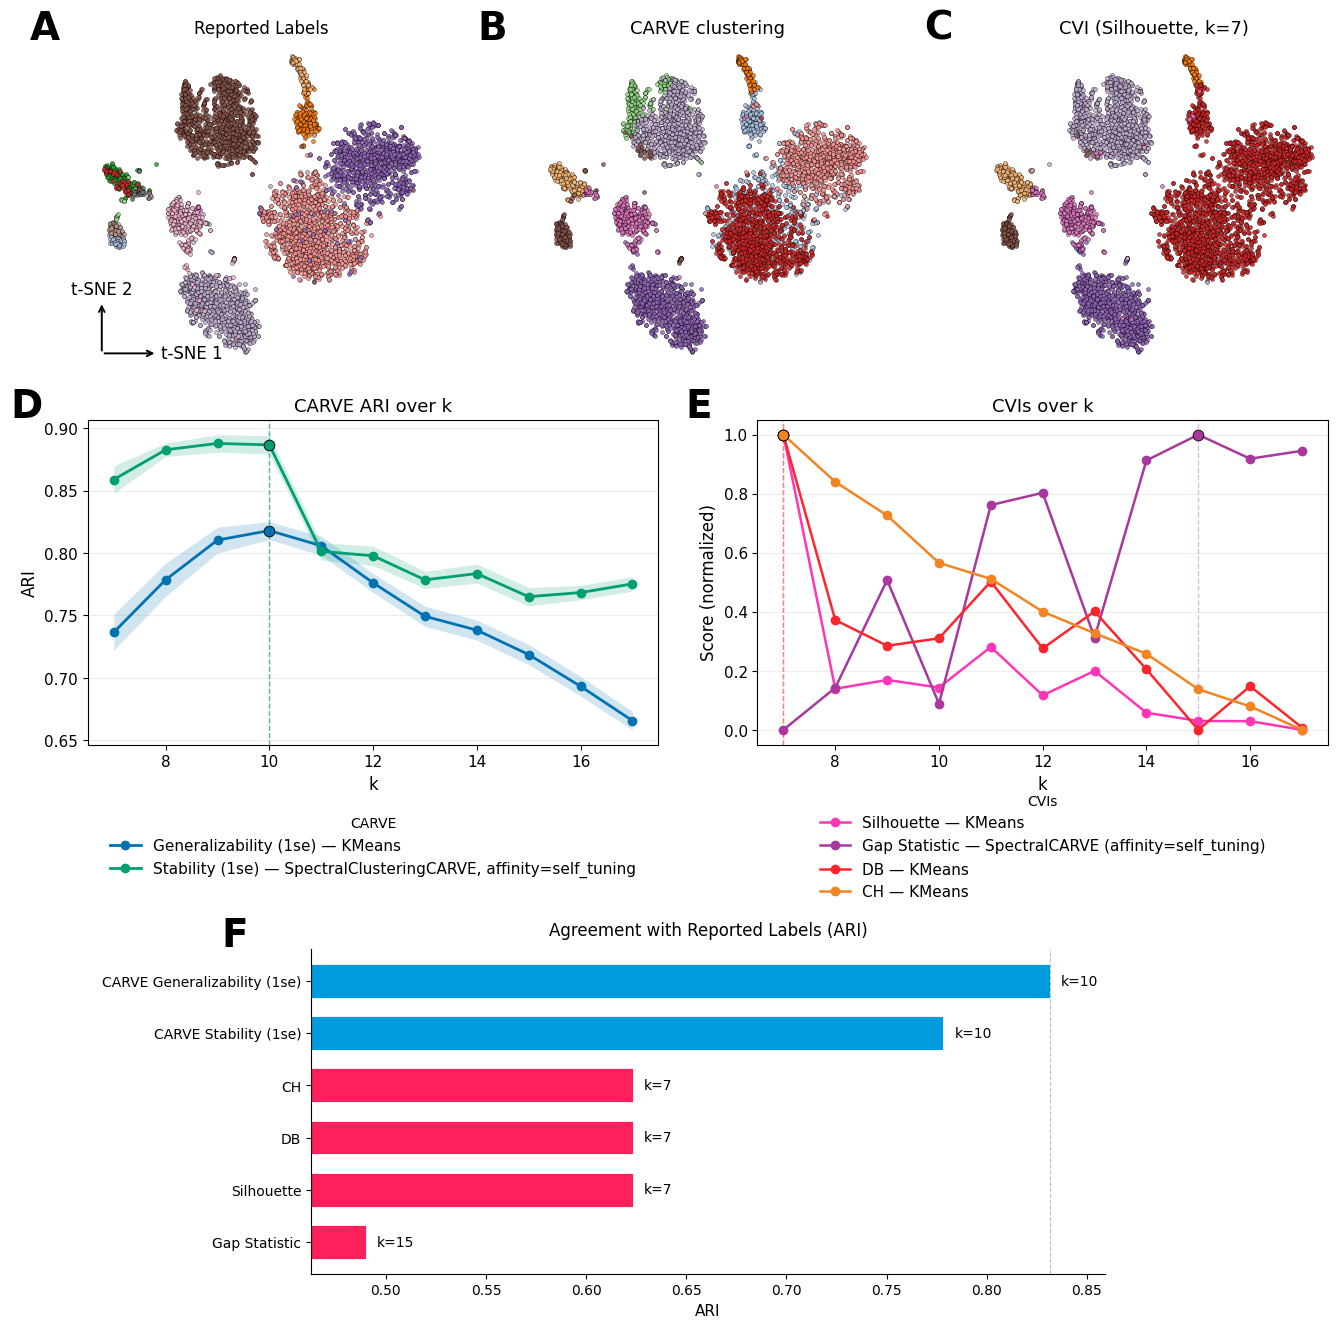

Comparison model used: KMeans (k=7)


In [17]:
# Choose baseline metric for panel C and the ARI bottom panel
# options: "silhouette", "gap", "DB", "CH"
comparison_metric = "silhouette"

comparison_labels, comparison_model, comparison_k = build_baseline_best_labels(
    X=X,
    best_df=best_df,
    model_grids=model_grids,
    metric=comparison_metric,
    random_state=RANDOM_SEED,
)

# Map shorthand to names used by prepare_composite_data
measure_map = {"s": "stability", "g": "generalizability"}
measure_for_plot = measure_map.get(MEASURE, MEASURE)

prepared = prepare_composite_data(
    X=X,
    y=y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y),
    carve_obj=carve,
    comparison_labels=comparison_labels,
    measure=measure_for_plot,
    rule=RULE,
    not_two=NOT_TWO,
    consensus_type="stability",
    embedding=tsne_embedding,  # use the precomputed t-SNE for panels A/B/C
)

# --- Composite paper figure ---------------------------------------------------
# Tweak figsize / hspace / wspace / height_ratios / letter font here.
fig = plt.figure(figsize=(16, 16), constrained_layout=False)
gs = fig.add_gridspec(
    4,
    6,
    height_ratios=[1.0, 1.0, 0.3, 1.0],
    hspace=0.2,
    wspace=0.8,
)
ax_A = fig.add_subplot(gs[0, 0:2])
ax_B = fig.add_subplot(gs[0, 2:4])
ax_C = fig.add_subplot(gs[0, 4:6])
ax_D = fig.add_subplot(gs[1, 0:3])
ax_E = fig.add_subplot(gs[1, 3:6])
ax_F = fig.add_subplot(gs[3, 1:5])

legend_ax_D = fig.add_subplot(gs[2, 0:3])
legend_ax_D.set_axis_off()
legend_ax_E = fig.add_subplot(gs[2, 3:6])
legend_ax_E.set_axis_off()

# Top row: scatters share the palette via `prepared`.
plot_dim_red(
    prepared["X"],
    y=prepared["y_arr"],
    ax=ax_A,
    axis_labels=("t-SNE 1", "t-SNE 2"),
    show_axis_labels=False,
    axis_arrows=True,
    Z=prepared["Z"],
    title="Reported Labels",
    s=8.0,
    alpha=0.85,
    linewidth=0.3,
    show_legend=False,
    hide_axes=True,
    show=False,
)
plot_cluster_scatter(
    prepared["X"],
    prepared["carve_labels"],
    ax=ax_B,
    color_map=prepared["carve_cmap"],
    Z=prepared["Z"],
    pca_obj=prepared["pca_obj"],
    s=8.0,
    alpha=0.85,
    title="CARVE clustering",
)
plot_cluster_scatter(
    prepared["X"],
    prepared["comparison_labels"],
    ax=ax_C,
    color_map=prepared["sil_cmap"],
    Z=prepared["Z"],
    pca_obj=prepared["pca_obj"],
    s=8.0,
    alpha=0.85,
    title=f"CVI ({comparison_metric.title()}, k={comparison_k})",
)

# Middle row: line plots.
plot_carve_best_lines(
    carve,
    ax=ax_D,
    title="CARVE ARI over k",
    not_two=NOT_TWO,
    annotate=False,
)
plot_baseline_best_lines(
    curves_df,
    best_df,
    ax=ax_E,
    title="CVIs over k",
)

# Bottom row: ARI lollipop.
ari_df = extract_ari_comparison(
    prepared["y_arr"],
    best_df,
    carve,
    prepared["X"],
    not_two=NOT_TWO,
)
plot_ari_comparison_bar(
    ari_df,
    ax=ax_F,
    title="Agreement with Reported Labels (ARI)",
)

# Handle legends
handles_D, labels_D = ax_D.get_legend_handles_labels()
ax_D.get_legend().remove()
handles_E, labels_E = ax_E.get_legend_handles_labels()
ax_E.get_legend().remove()

leg_D = legend_ax_D.legend(
    handles_D,
    labels_D,
    title="CARVE",
    loc="center left",
    bbox_to_anchor=(0.02, 0.5),
    ncol=1,
    frameon=False,
    fontsize=10,
)

leg_D = legend_ax_D.legend(
    handles_D,
    labels_D,
    title="CARVE",
    loc="center",
    ncol=1,
    frameon=False,
    fontsize=11,
)

leg_E = legend_ax_E.legend(
    handles_E,
    labels_E,
    title="CVIs",
    loc="center",
    ncol=1,
    frameon=False,
    fontsize=11,
)

# Panel letters — tweak fontsize / x,y here to taste.
for letter, ax in [
    ("A", ax_A),
    ("B", ax_B),
    ("C", ax_C),
    ("D", ax_D),
    ("E", ax_E),
    ("F", ax_F),
]:
    ax.text(
        -0.08,
        1.1,
        letter,
        transform=ax.transAxes,
        fontsize=28,
        fontweight="bold",
        va="top",
        ha="right",
    )

plt.show()
print(f"Comparison model used: {comparison_model} (k={comparison_k})")

In [ ]:
# see: https://github.com/lmweber/benchmark-data-Levine-32-dim
POPULATION_NAMES = {
    1: "Basophils", 2: "CD16- NK cells", 3: "CD16+ NK cells",
    4: "CD34+CD38+CD123- HSPCs", 5: "CD34+CD38+CD123+ HSPCs",
    6: "CD34+CD38lo HSCs", 7: "CD4 T cells", 8: "CD8 T cells",
    9: "Mature B cells", 10: "Monocytes", 11: "pDCs",
    12: "Plasma B cells", 13: "Pre-B cells", 14: "Pro-B cells",
}

true_names = pd.Series(np.asarray(prepared["y_arr"]).astype(int)).map(POPULATION_NAMES)

for name, labels in [
    (f"CVI (k={comparison_k})", prepared["comparison_labels"]),
    ("CARVE", prepared["carve_labels"])
]:
    ct = pd.crosstab(true_names, pd.Series(np.asarray(labels), name="cluster"))
    dominant = ct.idxmax(axis=1)
    
    print(f"\n=== {name}, {ct.shape[1]} clusters: true population & dominant cluster ===")
    print(dominant.sort_values().to_string())
    
    merged = dominant.groupby(dominant).apply(lambda s: list(s.index))
    merged = merged[merged.map(len) > 1]
    
    if len(merged):
        print("Populations sharing one cluster (i.e. merged):")
        for cl, pops in merged.items():
            print(f"  cluster {cl}: {pops}")
    else:
        print("No two true populations share a dominant cluster.")


=== CVI (k=7), 7 clusters: true population & dominant cluster ===
row_0
CD16+ NK cells             2
CD34+CD38+CD123- HSPCs     3
CD34+CD38lo HSCs           3
CD16- NK cells             6
CD4 T cells                6
CD8 T cells                6
Mature B cells             8
Monocytes                  9
Basophils                 10
CD34+CD38+CD123+ HSPCs    10
pDCs                      10
Plasma B cells            12
Pre-B cells               12
Pro-B cells               12
Populations sharing one cluster (i.e. merged):
  cluster 3: ['CD34+CD38+CD123- HSPCs', 'CD34+CD38lo HSCs']
  cluster 6: ['CD16- NK cells', 'CD4 T cells', 'CD8 T cells']
  cluster 10: ['Basophils', 'CD34+CD38+CD123+ HSPCs', 'pDCs']
  cluster 12: ['Plasma B cells', 'Pre-B cells', 'Pro-B cells']

=== CARVE, 10 clusters: true population & dominant cluster ===
row_0
CD16- NK cells             1
CD16+ NK cells             2
CD34+CD38+CD123- HSPCs     3
CD34+CD38lo HSCs           3
CD4 T cells                6
CD8 T cells 

---

## 6. Summary

Levine_32dim is a canonical CyTOF benchmark with 14 manually gated bone marrow populations. The heavy-tailed protein expression distributions, overlapping populations, and varying population sizes challenge classical distance-based validation indices. We compare CARVE's stability-based selection (measure=s, rule=1se, not_two=True) against four classical metrics and quantify agreement with the 14 ground-truth populations using ARI.

---